In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from Simulate import *
from BayesianExtractor import *
from AdamExtractor import *
from data_quartzsi import t_r_raw as t_r, A_r, A_s

In [2]:
#Global Variables
L = len(A_r)  # Match actual data length (2425)
deltat = (t_r[1]-t_r[0])*1e-12  # Time step from data
x_exp = A_r
true_x_exp = A_s

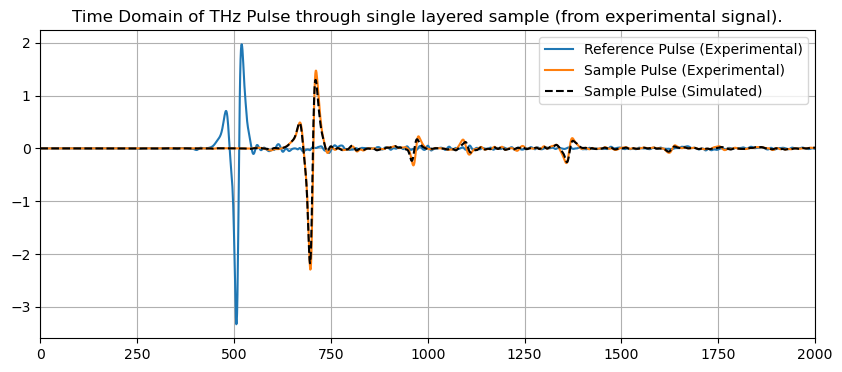

In [ ]:
#Inintial simulation
n_init = [1.982, 3.4]
k_init = [0.0071, 0.0054]
d_init = [1e-3, 0.4e-3]
layers= [(n_init[i] - 1j*k_init[i], d_init[i]) for i in range(2)]

T_exp, y_exp = simulate_from_signal(x_exp, layers, deltat)

#Plotting
y_exp = y_exp[:L].detach().cpu().numpy()
plt.figure(figsize=(10,4))
plt.title('Time Domain of THz Pulse through single layered sample (from experimental signal).')
plt.plot(x_exp, label='Reference Pulse (Experimental)')
plt.plot(true_x_exp, label='Sample Pulse (Experimental)')
plt.plot(y_exp, label='Sample Pulse (Simulated)', color = 'black', linestyle = '--')
plt.xlim(0,2000)
plt.legend()
plt.grid()
#plt.savefig("Quartzsi plots /Quartz plot.png")
plt.show()


In [4]:
#Bayesian Extraction
x_exp = torch.from_numpy(A_r)
true_x_exp = torch.from_numpy(A_s)

extractor = BayesianLayeredExtractor(reference_pulse=x_exp, 
                                     experimental_pulse=true_x_exp, 
                                     deltat=deltat, 
                                     layers_init= layers, 
                                     optimize_mask=[(True, True, True), (True, True, True)], 
                                     optimization_bounds=[0.4, 0.001, 50e-6])

best_layers = extractor.bayesian_optimization(n_calls=50)

#Finding induvidual values
n_complex_bays1, D_bays1 = best_layers[0]
n_bays1 = abs(n_complex_bays1.real)
k_bays1 = abs(n_complex_bays1.imag)
n_complex_bays2, D_bays2 = best_layers[1]
n_bays2 = abs(n_complex_bays2.real) 
k_bays2 = abs(n_complex_bays2.imag) 



Starting Bayesian Optimization with masks...
Search Boundaries for Optimized Parameters:
Layer 1 - n ∈ (1.5819999999999999, 2.382)
Layer 1 - k ∈ (-0.0081, -0.0061)
Layer 1 - D ∈ (0.00095, 0.00105)
Layer 2 - n ∈ (2.85, 3.65)
Layer 2 - k ∈ (-0.0064, -0.0044)
Layer 2 - D ∈ (0.00035, 0.00045000000000000004)


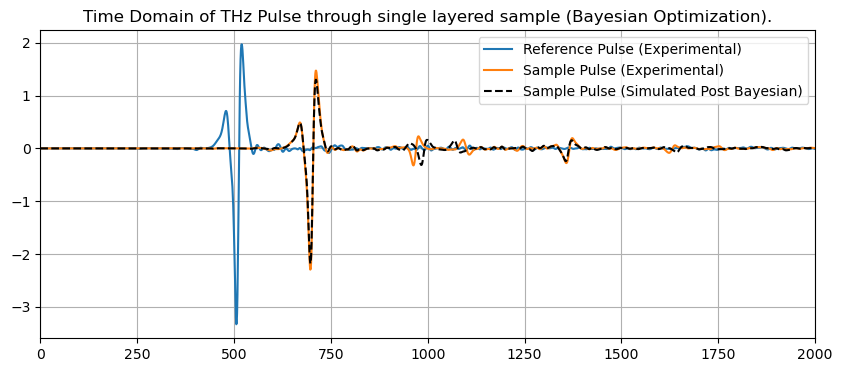

In [5]:
#Bayesian results
T_bays, y_bays = simulate_from_signal(x_exp, best_layers, deltat)
y_bays = y_bays[:L].detach().cpu().numpy()


plt.figure(figsize=(10,4))
plt.plot(x_exp, label='Reference Pulse (Experimental)')
plt.plot(true_x_exp, label='Sample Pulse (Experimental)')
plt.plot(y_bays, label='Sample Pulse (Simulated Post Bayesian)', color = 'black', linestyle = '--')
plt.title('Time Domain of THz Pulse through single layered sample (Bayesian Optimization).')
plt.xlim(0,2000)
plt.legend()
plt.grid()
#plt.savefig("Quartzsi plots /Quartz Bayesian.png")
plt.show()


In [6]:
#Adam Extraction post Bayesian
#Converting data into floats to work with Adam Extractor
x_exp = torch.from_numpy(A_r).float()
true_x_exp = torch.from_numpy(A_s).float()

adam_extractor = LayeredExtractor(x_exp, true_x_exp, deltat, best_layers, 
                                  optimize_mask=[(True, True, True), (True, True, True)])

adam_best_layers = adam_extractor.optimize(num_iterations=6000, 
                                           verbose=True, updates=200, alpha=1)

n_complex_adam1, D_adam1 = adam_best_layers[0]
n_adam1 = abs(n_complex_adam1.real)
k_adam1 = abs(n_complex_adam1.imag)
n_complex_adam2, D_adam2 = adam_best_layers[1]
n_adam2 = abs(n_complex_adam2.real)
k_adam2 = abs(n_complex_adam2.imag)


Fine-tuning 6 parameters for 6000 iterations.
Iteration 199, Loss: 1.125997e-02, Layer 0: n=1.9896, k=-0.00697, D=981.25 µm | Layer 1: n=3.3334, k=0.00588, D=394.57 µm
Iteration 399, Loss: 1.125522e-02, Layer 0: n=1.9905, k=-0.00708, D=980.80 µm | Layer 1: n=3.3296, k=0.00604, D=395.01 µm
Iteration 599, Loss: 1.125091e-02, Layer 0: n=1.9915, k=-0.00720, D=980.35 µm | Layer 1: n=3.3258, k=0.00621, D=395.48 µm
Iteration 799, Loss: 1.124768e-02, Layer 0: n=1.9923, k=-0.00729, D=979.94 µm | Layer 1: n=3.3223, k=0.00638, D=395.90 µm
Iteration 999, Loss: 1.124529e-02, Layer 0: n=1.9930, k=-0.00736, D=979.57 µm | Layer 1: n=3.3192, k=0.00653, D=396.27 µm
Iteration 1199, Loss: 1.124378e-02, Layer 0: n=1.9936, k=-0.00742, D=979.24 µm | Layer 1: n=3.3166, k=0.00666, D=396.58 µm
Iteration 1399, Loss: 1.126841e-02, Layer 0: n=1.9943, k=-0.00756, D=979.06 µm | Layer 1: n=3.3144, k=0.00671, D=396.87 µm
Iteration 1599, Loss: 1.124160e-02, Layer 0: n=1.9946, k=-0.00754, D=978.77 µm | Layer 1: n=3.3125

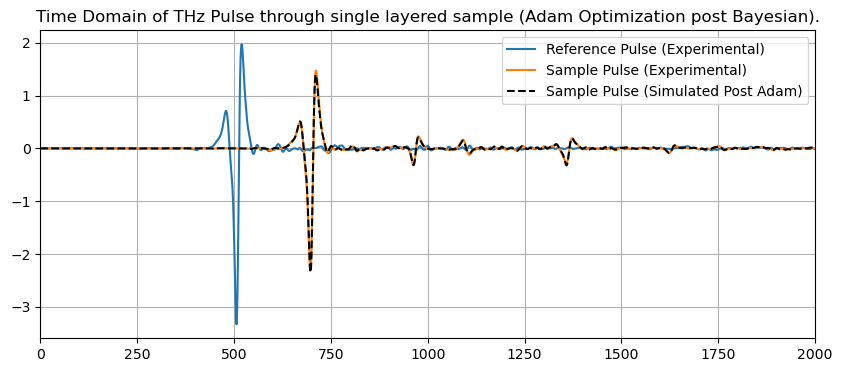

In [7]:
#Adam results
T_adam, y_adam = simulate_from_signal(x_exp, adam_best_layers, deltat)
y_adam = y_adam[:L].detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.plot(x_exp, label='Reference Pulse (Experimental)')
plt.plot(true_x_exp, label='Sample Pulse (Experimental)') 
plt.plot(y_adam, label='Sample Pulse (Simulated Post Adam)', color = 'black', linestyle = '--') 
plt.title('Time Domain of THz Pulse through single layered sample (Adam Optimization post Bayesian).')
plt.xlim(0,2000) 
plt.legend() 
plt.grid() 
#plt.savefig("Quartzsi plots /Quartz Adam.png") 
plt.show()


Multi-layer loss landscape visualization module loaded!
Use visualize_multilayer_landscape() to analyze each layer.

MULTI-LAYER LOSS LANDSCAPE ANALYSIS (2 layers)

Optimizer Results:
----------------------------------------------------------------------

Layer 1:
  Bayesian: n=1.9403, k=0.0061, d=950.00μm
  ADAM:     n=1.9967, k=0.0078, d=977.74μm

Layer 2:
  Bayesian: n=3.3872, k=0.0058, d=418.13μm
  ADAM:     n=3.3040, k=0.0073, d=398.10μm

ANALYZING LAYER 1

[Layer 1] Generating 1D parameter slices...
Saved: layer_1_1d_slices.png


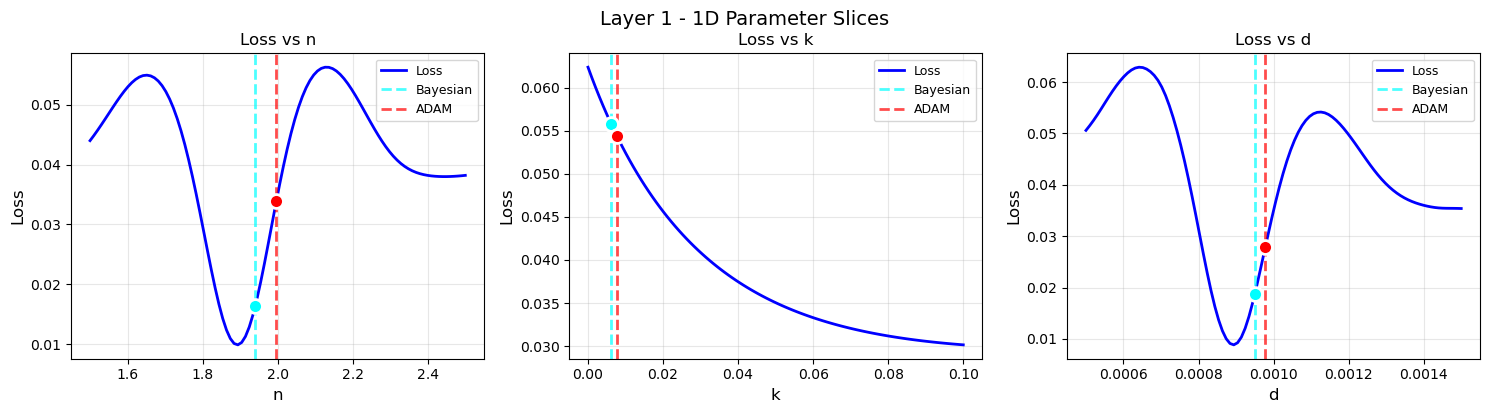


[Layer 1] Generating n vs k landscape...
Computing loss landscape for n vs k...
Saved: layer_1_n_vs_k.png


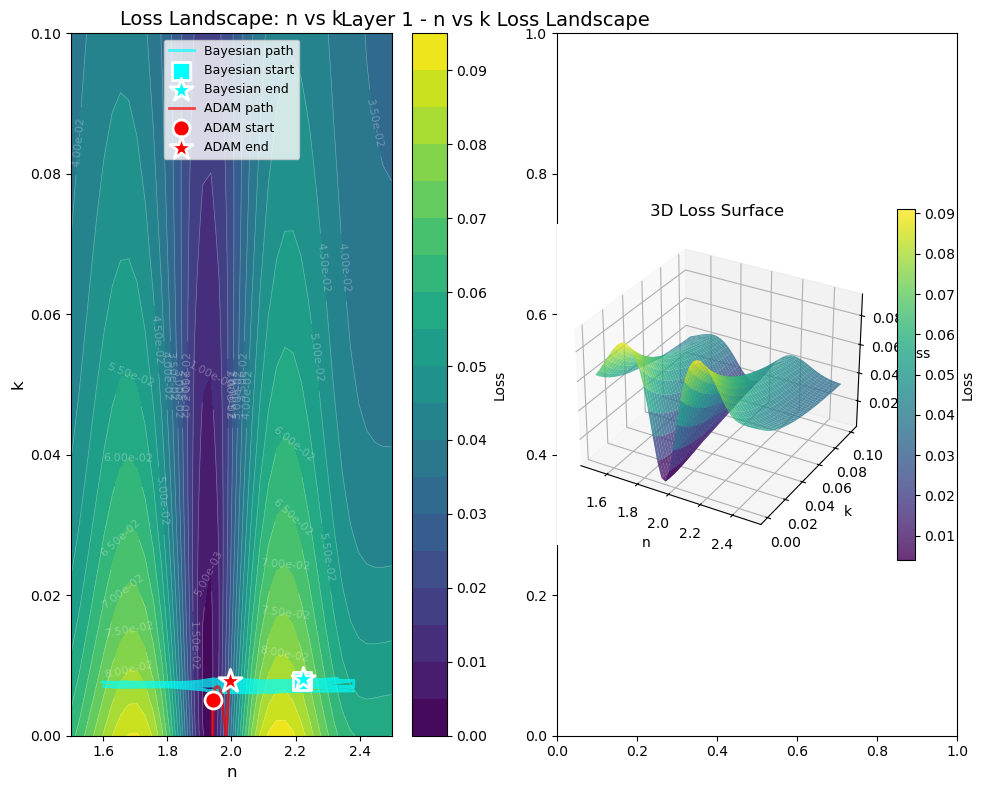


[Layer 1] Statistical local minima analysis...

LOCAL MINIMA ANALYSIS

Bayesian:
  Loss at solution: 2.651476e-03
  Random samples with lower loss: 0/2000 (0.0%)
  Min loss in samples: 2.868847e-03
  Mean loss in samples: 5.038300e-02
Appears to be near global minimum

ADAM:
  Loss at solution: 3.870960e-02
  Random samples with lower loss: 788/2000 (39.4%)
  Min loss in samples: 2.690077e-03
  Mean loss in samples: 4.824247e-02


ANALYZING LAYER 2

[Layer 2] Generating 1D parameter slices...
Saved: layer_2_1d_slices.png


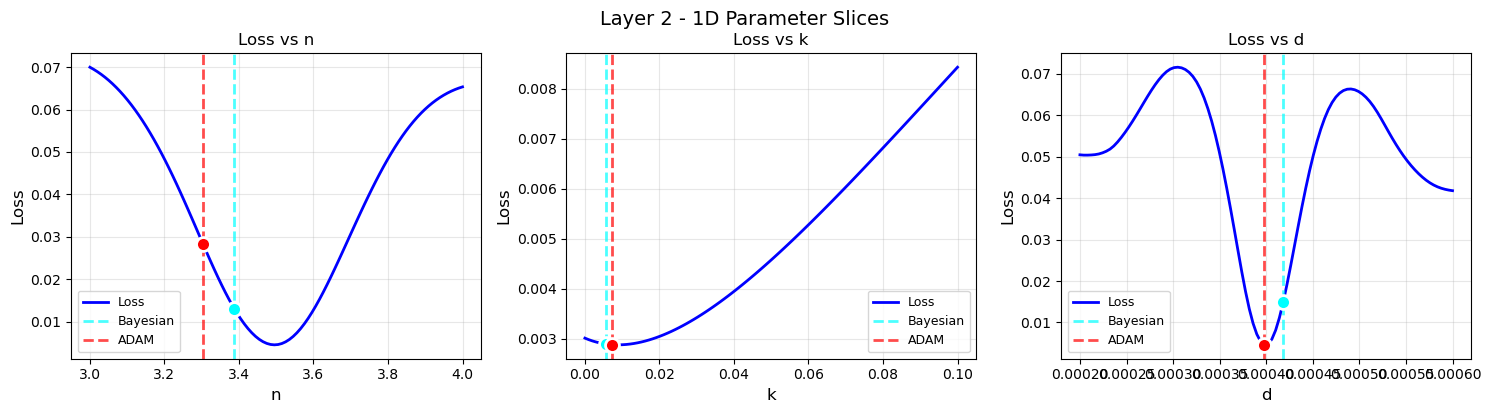


[Layer 2] Generating n vs k landscape...
Computing loss landscape for n vs k...
Saved: layer_2_n_vs_k.png


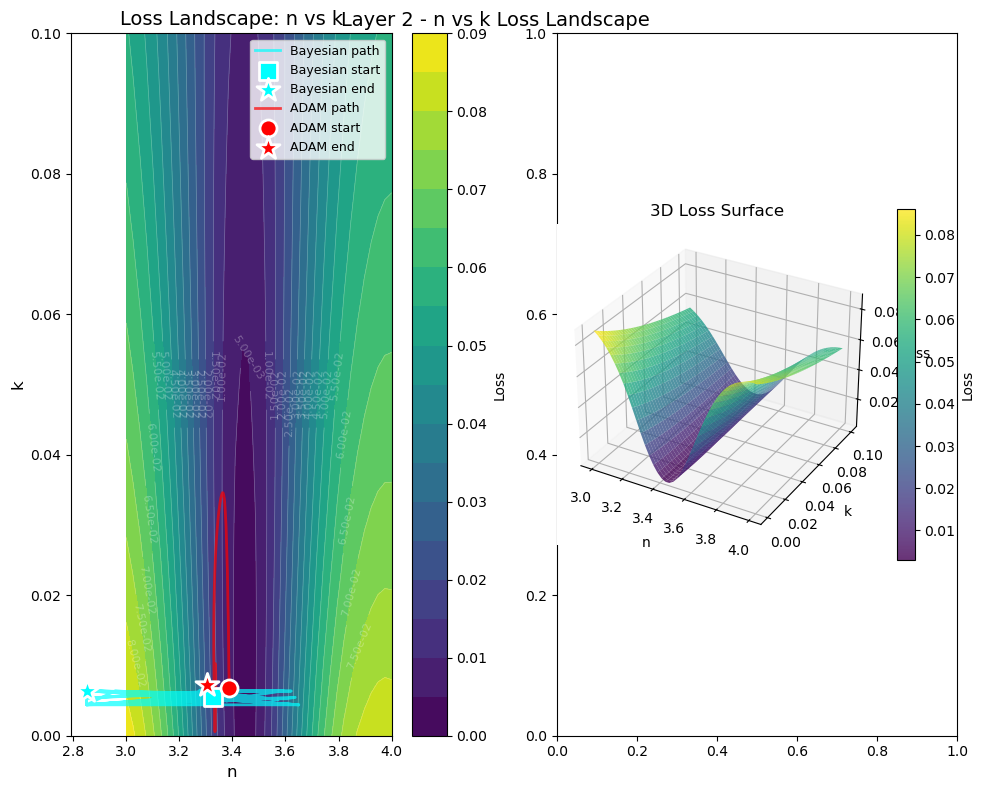


[Layer 2] Statistical local minima analysis...

LOCAL MINIMA ANALYSIS

Bayesian:
  Loss at solution: 2.651476e-03
  Random samples with lower loss: 5/2000 (0.2%)
  Min loss in samples: 2.529853e-03
  Mean loss in samples: 4.531375e-02
Appears to be near global minimum

ADAM:
  Loss at solution: 3.850064e-02
  Random samples with lower loss: 789/2000 (39.5%)
  Min loss in samples: 2.491058e-03
  Mean loss in samples: 4.937309e-02


SUMMARY: WHICH LAYERS ARE STUCK IN LOCAL MINIMA?

Layer 1:
  Bayesian better (0.0% vs 39.4%)

Layer 2:
  Bayesian better (0.2% vs 39.5%)

Generated 4 visualization files


In [8]:
#Loss landscape
from multilayer_loss_landscape import visualize_multilayer_landscape
param_ranges_per_layer = [
        # Layer 1
        {
            'n': (1.5, 2.5),    
            'k': (0.0, 0.1),
            'd': (0.5e-3, 1.5e-3) 
        },
        # Layer 2
        {
            'n': (3, 4),
            'k': (0.0, 0.1),
            'd': (0.2e-3, 0.6e-3)   
        }
    ]
    
    # Run multi-layer landscape analysis
analyses = visualize_multilayer_landscape(
    x_exp=x_exp,
    true_x_exp=true_x_exp, 
    deltat=deltat,
    L=L,
    bayesian_layers = best_layers,
    adam_layers=adam_best_layers,
    param_ranges_per_layer=param_ranges_per_layer,
    bayesian_history=extractor.iteration_history,  
    adam_history=adam_extractor.iteration_history,
    resolution=40) 


In [9]:
#Plotting loss landscape
# 1D slices
#analysis.plot_1d_slices(optimizer_values=final_values)
#plt.savefig('Loss landscape plots\1d_slices_2.png', dpi=300, bbox_inches='tight')
#plt.show()

# 2D landscape n vs k 
#analysis.plot_2d_slice('n', 'k', 
 #                 fixed_params={'d': (D_bays +   D_adam)/2},
  #                resolution=40)
#plt.savefig('Loss landscape plots\ landscape_n_vs_k_2.png', dpi=300, bbox_inches='tight')
#plt.show()

# Local minima test
#viz.analyze_local_minima(final_values, n_samples=2000)


In [10]:
#Printing the results
print("-------------------------------- RESULTS --------------------------------")
print("Initital values:")
print("layer 1: n = 2, k = 0.01, d = 1e-3")
print("layer 2: n = 1, k = 0.01, d = 119.2e-6")
print("layer 3: n = 2, k = 0.01, d = 1e-3")
print()
print("Bayesian Optimization Results:")
print("Layer 1: n =", np.round(n_bays1, 3), "k =", np.round(k_bays1, 5), "d =", np.round(D_bays1, 6))
print("Layer 2: n =", np.round(n_bays2, 3), "k =", np.round(k_bays2, 5), "d =", np.round(D_bays2, 6))
print()
print("Adam Optimization Results:")
print("Layer 1: n =", np.round(n_adam1, 3), "k =", np.round(k_adam1, 5), "d =", np.round(D_adam1, 6))
print("Layer 2: n =", np.round(n_adam2, 3), "k =", np.round(k_adam2, 5), "d =", np.round(D_adam2, 6))
print("-------------------------------------------------------------------------")   

-------------------------------- RESULTS --------------------------------
Initital values:
layer 1: n = 2, k = 0.01, d = 1e-3
layer 2: n = 1, k = 0.01, d = 119.2e-6
layer 3: n = 2, k = 0.01, d = 1e-3

Bayesian Optimization Results:
Layer 1: n = 1.94 k = 0.00614 d = 0.00095
Layer 2: n = 3.387 k = 0.00577 d = 0.000418

Adam Optimization Results:
Layer 1: n = 1.997 k = 0.00777 d = 0.000978
Layer 2: n = 3.304 k = 0.00726 d = 0.000398
-------------------------------------------------------------------------
